<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/%D0%9F%D0%BE%D0%BB%D0%BD%D0%BE%D1%81%D0%B2%D1%8F%D0%B7%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО: Власова Софья Юрьевна**

**Факт о себе: мне страшно читать задание**


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Начнем с того, что скачаем и загрузим данные:

In [ ]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-13 16:33:36--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [          <=>       ] 201.24M  43.1MB/s    in 4.9s    

2025-10-13 16:33:42 (40.8 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [ ]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

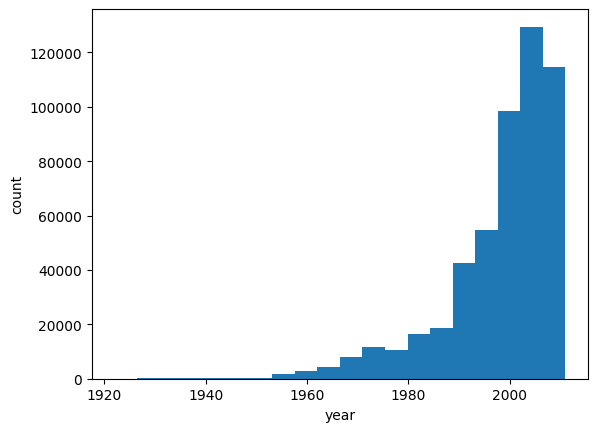

Range: 1922 - 2011
Unique values: 89


In [ ]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [ ]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [ ]:
# используется make_pipeline, об этой функции узнала из книги Рашка
# "Python и машинное обучение"

pipe_lr = make_pipeline(StandardScaler(),
                         Ridge())
param_range = [150.0, 200.0, 250.0, 1000.0]
param_grid = [{'ridge__alpha': param_range}]

gs = GridSearchCV(estimator=pipe_lr, # пайплайн обучения
                  param_grid=param_grid,
                  scoring='neg_mean_squared_error', # отрицательная MSE
                  cv=10, # кол-во фолдов данных
                  refit=True,
                  n_jobs=-1)

gs = gs.fit(X_train, y_train)
best_mse = abs(gs.best_score_)
best_rmse = np.sqrt(best_mse)  # RMSE
best_alpha = gs.best_params_['ridge__alpha']

print(f'Лучшая оценка (RMSE): {best_rmse:.4f}')
print(f'Оптимальное значение альфа: {best_alpha}')

Лучшая оценка (RMSE): 9.5854
Оптимальное значение альфа: 250.0


Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [ ]:
best_rmse_metric = np.sqrt((1/len(y_train))*np.sum((y_train-(np.mean(y_train)))**2))
best_rmse_metric

np.float64(10.959414043888264)

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

***Было принято решение отскалировать данные, потому что без этого сеть не учится, градиенты взрываются, а посмотреть как работает рукописный цикл обучения (и что лосс действительно падает) хочется.***

In [ ]:
Y_scaler = StandardScaler()
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

y_train_scaled = Y_scaler.fit_transform(y_train)
y_test_scaled = Y_scaler.transform(y_test)
y_val_scaled = Y_scaler.transform(y_val)

y_train_regression = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_regression = torch.tensor(y_test_scaled, dtype=torch.float32)
y_val_regression = torch.tensor(y_val_scaled, dtype=torch.float32)

y_train_classification = torch.tensor(y_train, dtype=torch.float32)
y_test_classification = torch.tensor(y_test, dtype=torch.float32)
y_val_classification = torch.tensor(y_val, dtype=torch.float32)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

dataloader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                      torch.tensor(y_train_regression, dtype=torch.float32)),
                        batch_size=32,
                        shuffle=True,
                        generator=g,
                        worker_init_fn=seed_worker)

/tmp/ipython-input-2645484554.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataloader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
/tmp/ipython-input-2645484554.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train_regression, dtype=torch.float32)),


In [ ]:
n_features = X_train.shape[-1]

model = nn.Sequential(
    nn.Linear(n_features, 1)
)

In [ ]:
# Функция ошибки (RMSE)
def rmse_loss(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2))

In [ ]:
num_epochs = 10
learning_rate = 0.01

# Функция обучения
def train(model, num_epochs, dataloader, x_test, y_test):
    loss_train = []
    loss_test = []

    for epoch in range(num_epochs):
        total_train_loss = 0.0
        count_batches = 0

        for x_batch, y_batch in dataloader:

            pred = model.forward(x_batch)
            loss = rmse_loss(pred, y_batch)
            loss.backward()

            with torch.no_grad():
                for param in model.parameters():
                    param -= learning_rate * param.grad

            model.zero_grad()

            total_train_loss += np.mean((Y_scaler.inverse_transform(pred.detach().numpy()) -
                                       Y_scaler.inverse_transform(y_batch.detach().numpy()))**2)


            count_batches += 1

        avg_train_loss = np.sqrt(total_train_loss / count_batches)
        loss_train.append(avg_train_loss)

        with torch.no_grad():
            test_preds = model(x_test)
        test_loss = np.mean((Y_scaler.inverse_transform(test_preds.detach().numpy()) -
                                       Y_scaler.inverse_transform(y_test.detach().numpy()))**2)

        loss_test.append(np.sqrt(test_loss))

        print(f'Эпоха [{epoch+1}/{num_epochs}], Train Loss: {loss_train[-1]:.4f}, Test Loss: {loss_test[-1]:.4f}')

    return loss_train, loss_test

Эпоха [1/10], Train Loss: 9.7064, Test Loss: 9.6589
Эпоха [2/10], Train Loss: 9.6746, Test Loss: 9.7507
Эпоха [3/10], Train Loss: 9.6731, Test Loss: 9.7085
Эпоха [4/10], Train Loss: 9.6754, Test Loss: 9.7179
Эпоха [5/10], Train Loss: 9.6757, Test Loss: 9.6902
Эпоха [6/10], Train Loss: 9.6773, Test Loss: 9.7405
Эпоха [7/10], Train Loss: 9.6759, Test Loss: 9.6920
Эпоха [8/10], Train Loss: 9.6761, Test Loss: 9.7049
Эпоха [9/10], Train Loss: 9.6754, Test Loss: 9.6828
Эпоха [10/10], Train Loss: 9.6762, Test Loss: 9.6776


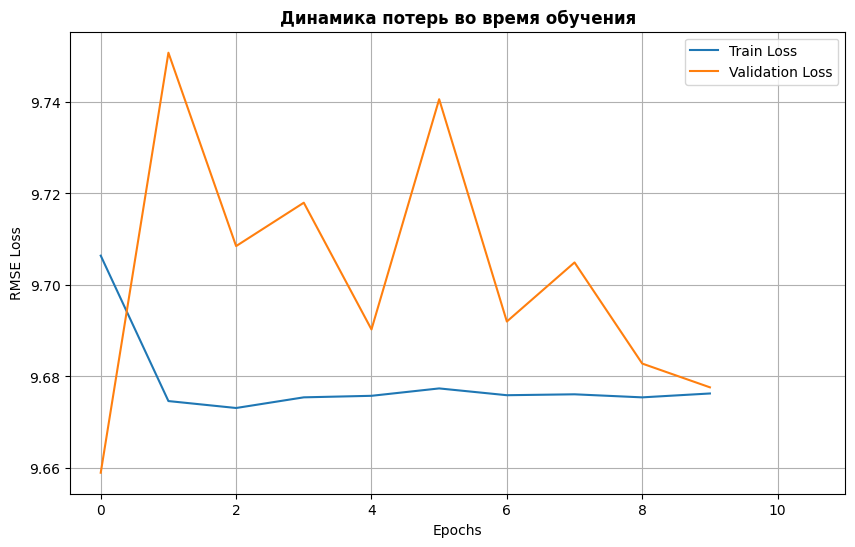

In [ ]:
history = train(model, num_epochs=num_epochs, dataloader=dataloader,
                x_test=X_val,
                y_test=y_val_regression)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history[0], label="Train Loss")
plt.plot(history[1], label="Validation Loss")
plt.xlabel("Epochs")
plt.xlim(right=11)
plt.ylabel("RMSE Loss")
plt.title("Динамика потерь во время обучения", fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_preds = model(X_test)
test_loss = np.mean((Y_scaler.inverse_transform(test_preds.detach().numpy()) -
                                       Y_scaler.inverse_transform(y_test_regression.detach().numpy()))**2)
np.sqrt(test_loss) # проверка лосса на тесте

np.float32(9.554148)

Из-за того, что мы нормализовали значения обучающих данных, обученная модель показывает хорошие результаты на тесте, давая качество, сравнимое с бэйзлайном.

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [ ]:
def prepare_datasets(X, y):
  train_size = int(0.75 * X.shape[0])

  X_train = X[:train_size, :]
  y_train = y[:train_size]
  X_test = X[train_size:, :]
  y_test = y[train_size:]

  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)

  # y_train = y_train.reshape(-1, 1)
  # y_test = y_test.reshape(-1, 1)
  # y_val = y_val.reshape(-1, 1)

  y_train = torch.tensor(y_train, dtype=torch.float32)
  y_test = torch.tensor(y_test, dtype=torch.float32)
  y_val = torch.tensor(y_val, dtype=torch.float32)

  X_train = torch.tensor(X_train, dtype=torch.float32)
  X_test = torch.tensor(X_test, dtype=torch.float32)
  X_val = torch.tensor(X_val, dtype=torch.float32)

  return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
def return_years(predict_labels, min_year):
    return predict_labels * 10 + min_year

In [ ]:
def rmse_loss(pred, target):
  pred_float = pred.type(torch.float32)  # Приводим к float32
  target_float = target.type(torch.float32)  # Приводим к float32
  return torch.sqrt(torch.mean((pred_float - target_float) ** 2))

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with val set
    """
    model.train()
    train_loss = 0
    count_batches = 0
    for x_train, y_train in train_loader:
        x_train, y_train = x_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        output = model(x_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_loss += rmse_loss(return_years(torch.max(output.data, dim=1)[1], 1922), return_years(y_train, 1922))
        count_batches += 1
    return train_loss / count_batches


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    for x_val, y_val in val_loader:
        x_val, y_val = x_val.to(device), y_val.to(device)

        outputs = model(x_val)
        _, predicted = torch.max(outputs.data, 1)

        loss = criterion(outputs, y_val)
        val_loss += rmse_loss(return_years(predicted, 1922), return_years(y_val, 1922))

        total += 1

    avg_val_loss = val_loss / total
    return avg_val_loss


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    model.eval()  # Устанавливаем модель в режим оценки
    predicts = []

    for inputs, _ in data_loader:  # Игнорируем цели (_)
        inputs = inputs.to(device)  # Переносим на устройство
        outputs = model(inputs)     # Прямой проход через модель
        _, preds = torch.max(outputs.data, 1)  # Берем индексы предсказанных классов
        predicts.append(preds)  # Сохраняем как тензор

    return torch.cat(predicts).cpu()


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_l = training_epoch(model, optimizer, criterion, train_loader)
        val_l = validation_epoch(model, criterion, val_loader)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_l:.4f}, Val Loss: {val_l:.4f}')

        train_losses.append(train_l)
        val_losses.append(val_l)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Динамика потерь во время обучения", fontweight='bold')
    plt.legend()
    plt.grid(True)
    plt.show()


**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [ ]:
np.unique(y, return_index=False, return_inverse=False, return_counts=False, axis=None)

array([1922, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933,
       1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944,
       1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955,
       1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966,
       1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977,
       1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988,
       1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011])

In [ ]:
codes = y // 10
class_labels = codes - codes.min()
labels = np.unique(class_labels, return_index=False, return_inverse=False, return_counts=False, axis=None)

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_datasets(X, class_labels)

Закодировала каждое десятилетие, получилось ровно 10 классов

In [ ]:
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                       torch.tensor(y_train, dtype=torch.int64)), batch_size=batch_size, shuffle=False,
                                       generator=g,
                                       worker_init_fn=seed_worker)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                     torch.tensor(y_val, dtype=torch.int64)), batch_size=batch_size, shuffle=False,
                                     generator=g,
                                     worker_init_fn=seed_worker)

/tmp/ipython-input-627283774.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
/tmp/ipython-input-627283774.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.int64)), batch_size=batch_size, shuffle=False,
/tmp/ipython-input-627283774.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
/tmp/ipython-input-627283774.py:7: UserWarning: To copy 

In [ ]:
inputs = X_train.shape[1]

In [ ]:
classes = len(labels)

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, classes),
).to(device)

Epoch 1/3, Train Loss: 13.3210, Val Loss: 12.4248
Epoch 2/3, Train Loss: 12.4074, Val Loss: 12.6527
Epoch 3/3, Train Loss: 12.4045, Val Loss: 12.4117


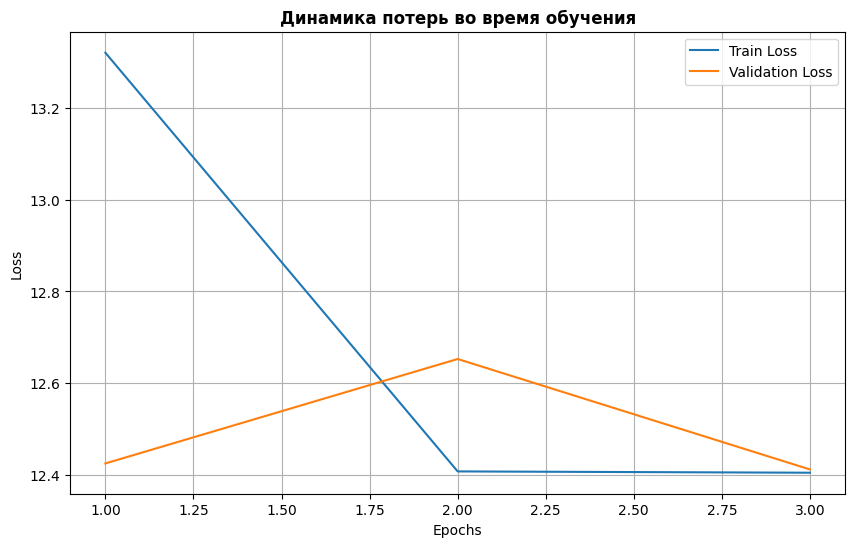

In [ ]:
num_epochs = 3
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

In [ ]:
test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.int64)), batch_size=batch_size, shuffle=True)
predictions = predict(model, test_loader)
rmse = rmse_loss(return_years(predictions, 1922), return_years(y_test, 1922))
print(f"RMSE: {rmse}")

/tmp/ipython-input-438044353.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
/tmp/ipython-input-438044353.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_test, dtype=torch.int64)), batch_size=batch_size, shuffle=True)


RMSE: 12.604229927062988


**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** далеко до бейзлайна, ошибка большая. Думаю, что учить классификатор для этой задачи - не лучшая идея. Можно посмотреть как минимум на распределение таргета и понять, что у нас в датасете наблюдается сильный дисбаланс классов, а если я кодирую таргет "десятилетками", то логично предположить, что количество объектов, причисляемых к разным классам будет сильно варьироваться, что ухудшит обучение.


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [ ]:
def prepare_datasets(X, y, norm=False):
  train_size = int(0.75 * X.shape[0])

  X_train = X[:train_size, :]
  y_train = y[:train_size]
  X_test = X[train_size:, :]
  y_test = y[train_size:]

  if norm:
    y_train = normalize(y_train)
    y_test = normalize(y_test)

  X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)

  y_train = y_train.reshape(-1, 1)
  y_test = y_test.reshape(-1, 1)
  y_val = y_val.reshape(-1, 1)

  y_train = torch.tensor(y_train, dtype=torch.float32)
  y_test = torch.tensor(y_test, dtype=torch.float32)
  y_val = torch.tensor(y_val, dtype=torch.float32)

  X_train = torch.tensor(X_train, dtype=torch.float32)
  X_test = torch.tensor(X_test, dtype=torch.float32)
  X_val = torch.tensor(X_val, dtype=torch.float32)

  return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
import math

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with val set
    """
    model.train()
    train_loss = 0
    count_batches = 0
    for x_train, y_train in train_loader:
        x_train, y_train = x_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        output = model(x_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_loss += math.sqrt(loss.item())
        count_batches += 1
    return train_loss / count_batches


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    model.eval()
    val_loss = 0
    total = 0

    for x_val, y_val in val_loader:
        x_val, y_val = x_val.to(device), y_val.to(device)

        outputs = model(x_val)
        loss = criterion(outputs, y_val)
        val_loss += math.sqrt(loss.item())
        total += 1

    avg_val_loss = val_loss / total
    return avg_val_loss


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    model.eval()  # Устанавливаем модель в режим оценки
    predicts = []

    for inputs, _ in data_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predicts.append(outputs)  # Сохраняем как тензор

    return torch.cat(predicts).cpu()


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_l = training_epoch(model, optimizer, criterion, train_loader)
        val_l = validation_epoch(model, criterion, val_loader)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_l:.4f}, Val Loss: {val_l:.4f}')

        train_losses.append(train_l)
        val_losses.append(val_l)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Динамика потерь во время обучения", fontweight='bold')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_datasets(X, y)

In [ ]:
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                       torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=False,
                                       generator=g,
                                       worker_init_fn=seed_worker)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                     torch.tensor(y_val, dtype=torch.float32)), batch_size=batch_size, shuffle=False,
                                     generator=g,
                                     worker_init_fn=seed_worker)

/tmp/ipython-input-2638712790.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
/tmp/ipython-input-2638712790.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=False,
/tmp/ipython-input-2638712790.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
/tmp/ipython-input-2638712790.py:7: UserWarning: To

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
).to(device)

Epoch 1/3, Train Loss: 1902.3844, Val Loss: 1902.4091
Epoch 2/3, Train Loss: 1902.2573, Val Loss: 1902.2858
Epoch 3/3, Train Loss: 1902.1341, Val Loss: 1902.1626


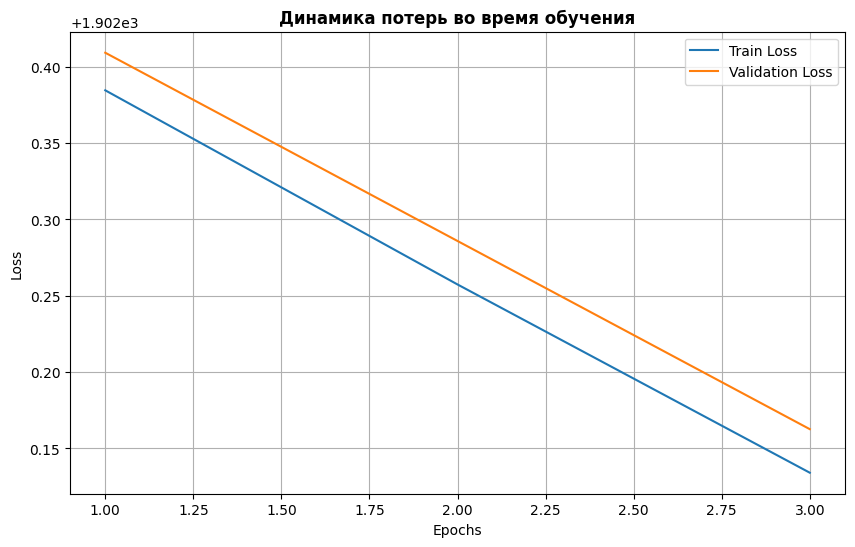

In [ ]:
num_epochs = 3
optimizer = torch.optim.SGD(model.parameters(), lr=1e-15)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** какое бы маленькое значение lr не использовалось, стабилизировать обучение не получилось. В ненормализованных данных признаки сильно отличаются друг от друга по масштабу, что очевидно приведет к плохому качеству модели на валидации.

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [ ]:
y_train = y[:int(0.75 * X.shape[0])]

MIN_VALUE = min(y_train)
MAX_VALUE = max(y_train)

def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    norm_s = (sample - MIN_VALUE) / (MAX_VALUE - MIN_VALUE)
    return norm_s

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (MAX_VALUE - MIN_VALUE) + MIN_VALUE

In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_datasets(X, y, norm=True)

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [ ]:
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                       torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=False,
                                       generator=g,
                                       worker_init_fn=seed_worker)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                     torch.tensor(y_val, dtype=torch.float32)), batch_size=batch_size, shuffle=False)

/tmp/ipython-input-970365771.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
/tmp/ipython-input-970365771.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=False,
/tmp/ipython-input-970365771.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
/tmp/ipython-input-970365771.py:7: UserWarning: To cop

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
).to(device)

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with val set
    """
    model.train()
    train_loss = 0
    count_batches = 0
    for x_train, y_train in train_loader:
        x_train, y_train = x_train.to(device), y_train.to(device)
        optimizer.zero_grad()
        output = model(x_train)
        loss = criterion(denormalize(output), denormalize(y_train))
        loss.backward()
        optimizer.step()
        train_loss += math.sqrt(loss.item())
        count_batches += 1
    return train_loss / count_batches


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """
    model.eval()
    val_loss = 0
    total = 0

    for x_val, y_val in val_loader:
        x_val, y_val = x_val.to(device), y_val.to(device)

        outputs = model(x_val)
        loss = criterion(denormalize(outputs), denormalize(y_val))
        val_loss += math.sqrt(loss.item())
        total += 1

    avg_val_loss = val_loss / total
    return avg_val_loss


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    model.eval()  # Устанавливаем модель в режим оценки
    predicts = []

    for inputs, _ in data_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predicts.append(outputs)  # Сохраняем как тензор

    return torch.cat(predicts).cpu()


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_l = training_epoch(model, optimizer, criterion, train_loader)
        val_l = validation_epoch(model, criterion, val_loader)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_l:.4f}, Val Loss: {val_l:.4f}')

        train_losses.append(train_l)
        val_losses.append(val_l)

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Динамика потерь во время обучения", fontweight='bold')
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch 1/3, Train Loss: 16.4938, Val Loss: 16.5041
Epoch 2/3, Train Loss: 16.4902, Val Loss: 16.5041
Epoch 3/3, Train Loss: 16.4902, Val Loss: 16.5041


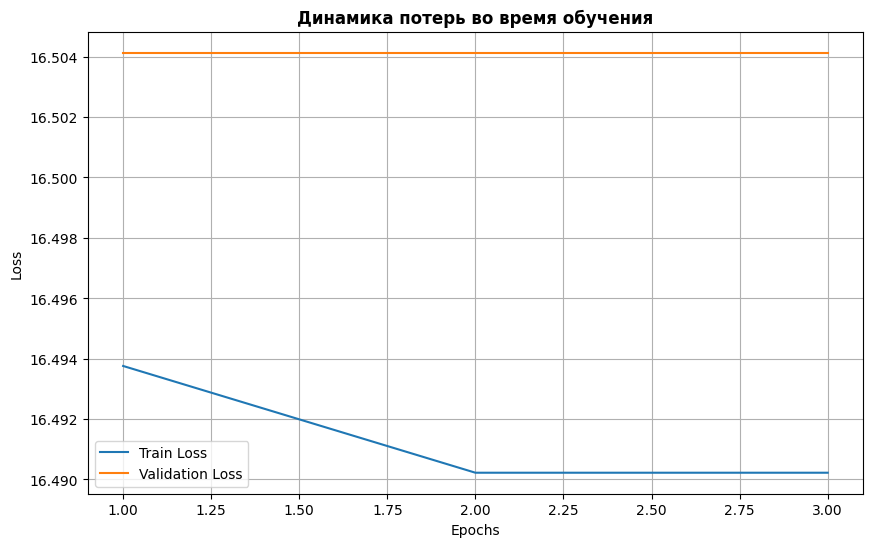

In [ ]:
num_epochs = 3
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
).to(device)

In [ ]:
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                       torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=False, generator=g,
                                       worker_init_fn=seed_worker)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                     torch.tensor(y_val, dtype=torch.float32)), batch_size=batch_size, shuffle=False, generator=g,
                                       worker_init_fn=seed_worker)

/tmp/ipython-input-2222140232.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
/tmp/ipython-input-2222140232.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.float32)), batch_size=batch_size, shuffle=False, generator=g,
/tmp/ipython-input-2222140232.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
/tmp/ipython-input-2222140232.py:6: Us

Epoch 1/10, Train Loss: 9.2050, Val Loss: 9.1386
Epoch 2/10, Train Loss: 9.0503, Val Loss: 9.0130
Epoch 3/10, Train Loss: 9.0221, Val Loss: 9.0552
Epoch 4/10, Train Loss: 9.0050, Val Loss: 9.0418
Epoch 5/10, Train Loss: 8.9956, Val Loss: 9.0308
Epoch 6/10, Train Loss: 8.9997, Val Loss: 8.9603
Epoch 7/10, Train Loss: 8.9544, Val Loss: 9.2846
Epoch 8/10, Train Loss: 8.9447, Val Loss: 9.0916
Epoch 9/10, Train Loss: 8.9314, Val Loss: 8.9758
Epoch 10/10, Train Loss: 8.9364, Val Loss: 9.0730


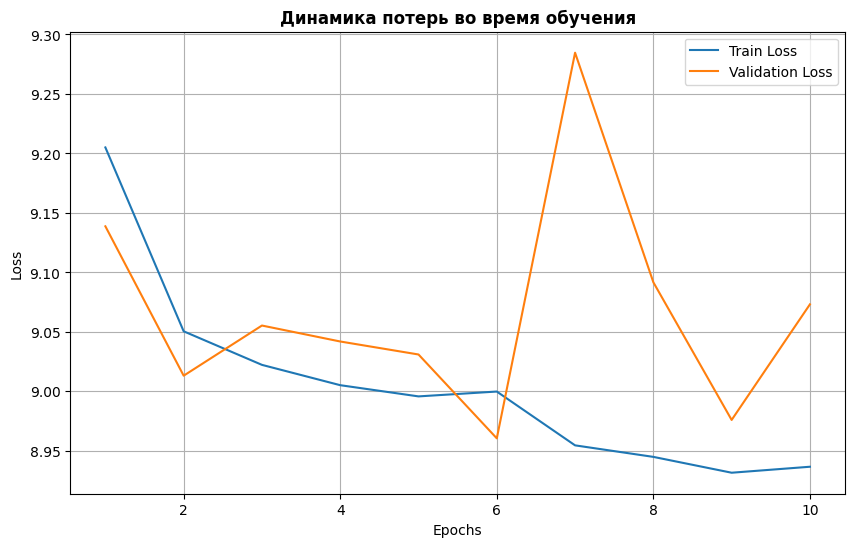

In [ ]:
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
).to(device)

Epoch 1/10, Train Loss: 8.9791, Val Loss: 8.7963
Epoch 2/10, Train Loss: 8.7141, Val Loss: 8.7419
Epoch 3/10, Train Loss: 8.6474, Val Loss: 8.7140
Epoch 4/10, Train Loss: 8.6001, Val Loss: 8.6999
Epoch 5/10, Train Loss: 8.5640, Val Loss: 8.6844
Epoch 6/10, Train Loss: 8.5322, Val Loss: 8.6764
Epoch 7/10, Train Loss: 8.5059, Val Loss: 8.6709
Epoch 8/10, Train Loss: 8.4834, Val Loss: 8.6648
Epoch 9/10, Train Loss: 8.4645, Val Loss: 8.6639
Epoch 10/10, Train Loss: 8.4463, Val Loss: 8.6615


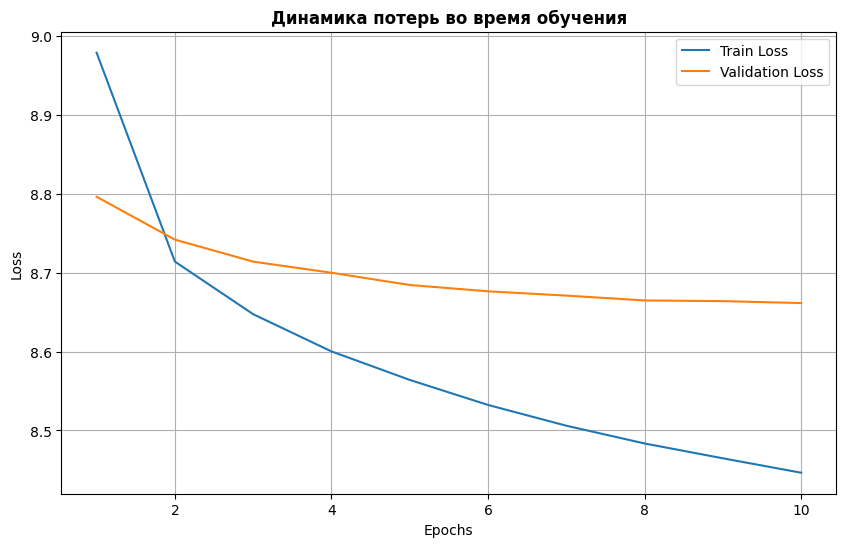

In [ ]:
num_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=1e-5, momentum=0.9)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, 1),
    nn.Sigmoid(),
).to(device)

Epoch 1/10, Train Loss: 9.0600, Val Loss: 8.8075
Epoch 2/10, Train Loss: 8.7217, Val Loss: 8.7399
Epoch 3/10, Train Loss: 8.6451, Val Loss: 8.7042
Epoch 4/10, Train Loss: 8.5922, Val Loss: 8.7139
Epoch 5/10, Train Loss: 8.5541, Val Loss: 8.7023
Epoch 6/10, Train Loss: 8.5225, Val Loss: 8.6682
Epoch 7/10, Train Loss: 8.4932, Val Loss: 8.6918
Epoch 8/10, Train Loss: 8.4687, Val Loss: 8.6770
Epoch 9/10, Train Loss: 8.4456, Val Loss: 8.6955
Epoch 10/10, Train Loss: 8.4251, Val Loss: 8.6843


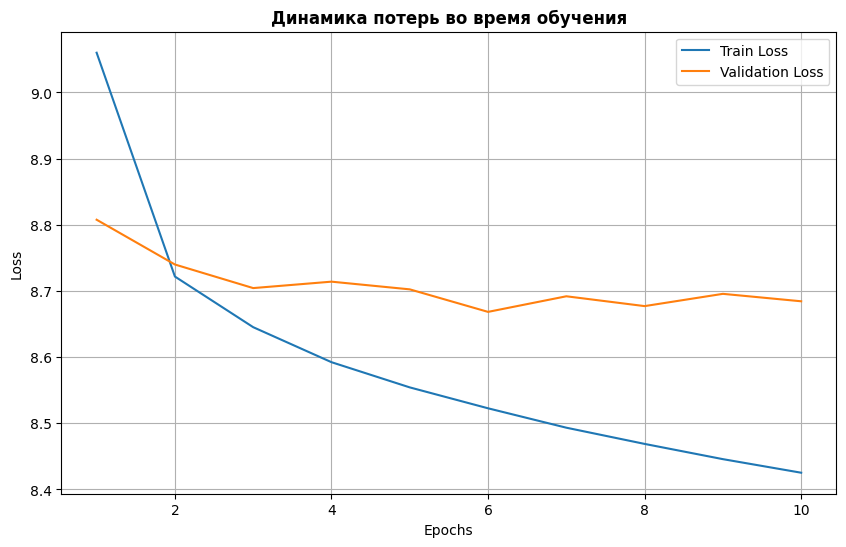

In [ ]:
num_epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

***Momentum и Adam в целом схожи по результатам обучения, в дальнейших экспериментах было принято решение использовать Adam.***

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Epoch 1/10, Train Loss: 9.0086, Val Loss: 8.7980
Epoch 2/10, Train Loss: 8.7158, Val Loss: 8.7252
Epoch 3/10, Train Loss: 8.6374, Val Loss: 8.7460
Epoch 4/10, Train Loss: 8.5837, Val Loss: 8.7171
Epoch 5/10, Train Loss: 8.5336, Val Loss: 8.7312
Epoch 6/10, Train Loss: 8.4933, Val Loss: 8.7065
Epoch 7/10, Train Loss: 8.4581, Val Loss: 8.7351
Epoch 8/10, Train Loss: 8.4267, Val Loss: 8.7040
Epoch 9/10, Train Loss: 8.3921, Val Loss: 8.7150
Epoch 10/10, Train Loss: 8.3684, Val Loss: 8.7407


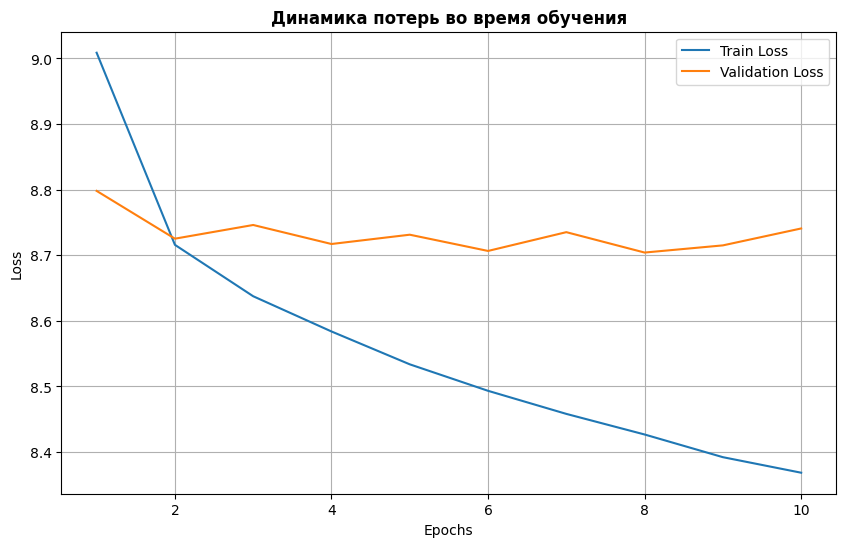

In [ ]:
# более широкая
model = nn.Sequential(
    nn.Linear(inputs, 256),
    nn.ReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid(),
).to(device)

num_epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

Epoch 1/10, Train Loss: 8.9212, Val Loss: 8.7502
Epoch 2/10, Train Loss: 8.6366, Val Loss: 8.6689
Epoch 3/10, Train Loss: 8.5374, Val Loss: 8.6310
Epoch 4/10, Train Loss: 8.4648, Val Loss: 8.6042
Epoch 5/10, Train Loss: 8.3992, Val Loss: 8.5849
Epoch 6/10, Train Loss: 8.3445, Val Loss: 8.5736
Epoch 7/10, Train Loss: 8.2934, Val Loss: 8.5928
Epoch 8/10, Train Loss: 8.2517, Val Loss: 8.6057
Epoch 9/10, Train Loss: 8.2108, Val Loss: 8.5998
Epoch 10/10, Train Loss: 8.1788, Val Loss: 8.6011


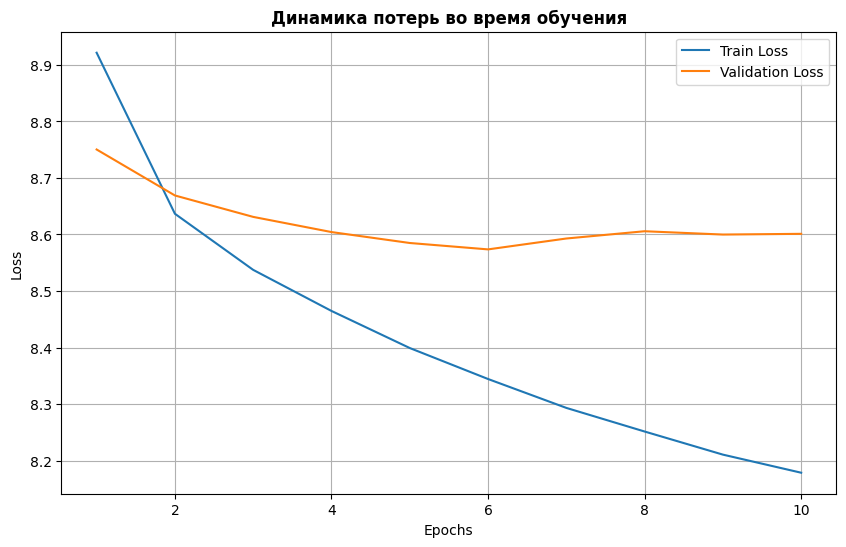

In [ ]:
# более глубокая
model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
).to(device)

num_epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

1. При увеличении ширины нейронной сети качество немного улучшилось, но не сильно (в сравнении с использованием более узкой нейронной сети). Из этого можно сделать вывод, что изменение скрытых слоев не так кардинально влияет на качество полученной модели.

2. При увеличении глубины нейронной сети качество улучшилось больше. Минимальное значение ошибки на валидационной выборки равно 8.58, а на тренировочной 8.23. Но после 7 эпохи можель начала переобучаться (ошибка на валидации стала постепенно расти, тогда как на тесте все так же снижаться).

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Epoch 1/10, Train Loss: 9.1600, Val Loss: 8.7839
Epoch 2/10, Train Loss: 8.8253, Val Loss: 8.7104
Epoch 3/10, Train Loss: 8.7485, Val Loss: 8.6605
Epoch 4/10, Train Loss: 8.6975, Val Loss: 8.6349
Epoch 5/10, Train Loss: 8.6605, Val Loss: 8.6063
Epoch 6/10, Train Loss: 8.6286, Val Loss: 8.5945
Epoch 7/10, Train Loss: 8.6015, Val Loss: 8.5790
Epoch 8/10, Train Loss: 8.5872, Val Loss: 8.5602
Epoch 9/10, Train Loss: 8.5600, Val Loss: 8.5596
Epoch 10/10, Train Loss: 8.5480, Val Loss: 8.5423


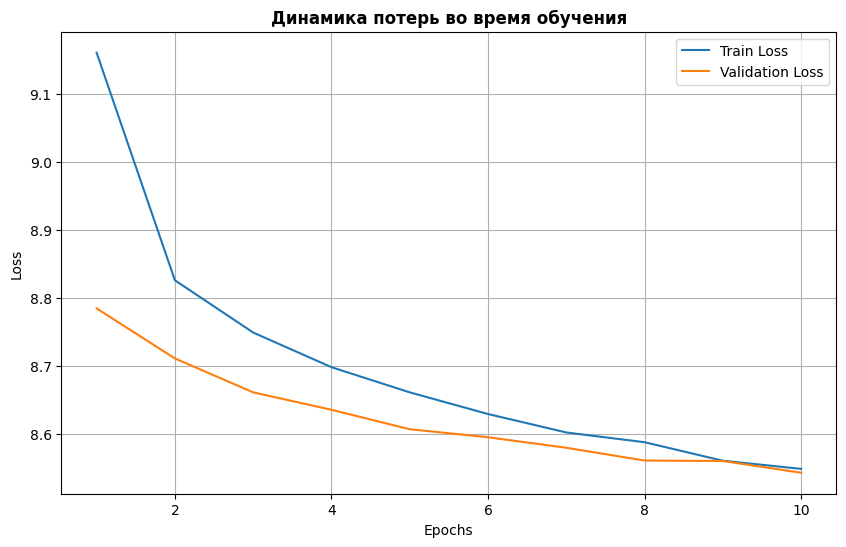

In [ ]:
# добавляю Dropout

model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.Dropout(p=0.2),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
).to(device)

num_epochs = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

Epoch 1/15, Train Loss: 9.1671, Val Loss: 8.7382
Epoch 2/15, Train Loss: 8.7356, Val Loss: 8.6590
Epoch 3/15, Train Loss: 8.6215, Val Loss: 8.6128
Epoch 4/15, Train Loss: 8.5435, Val Loss: 8.6025
Epoch 5/15, Train Loss: 8.4849, Val Loss: 8.5931
Epoch 6/15, Train Loss: 8.4352, Val Loss: 8.5903
Epoch 7/15, Train Loss: 8.3884, Val Loss: 8.5975
Epoch 8/15, Train Loss: 8.3474, Val Loss: 8.5996
Epoch 9/15, Train Loss: 8.3098, Val Loss: 8.6127
Epoch 10/15, Train Loss: 8.2795, Val Loss: 8.6132
Epoch 11/15, Train Loss: 8.2506, Val Loss: 8.6274
Epoch 12/15, Train Loss: 8.2228, Val Loss: 8.6301
Epoch 13/15, Train Loss: 8.1979, Val Loss: 8.6290
Epoch 14/15, Train Loss: 8.1766, Val Loss: 8.6490
Epoch 15/15, Train Loss: 8.1546, Val Loss: 8.6529


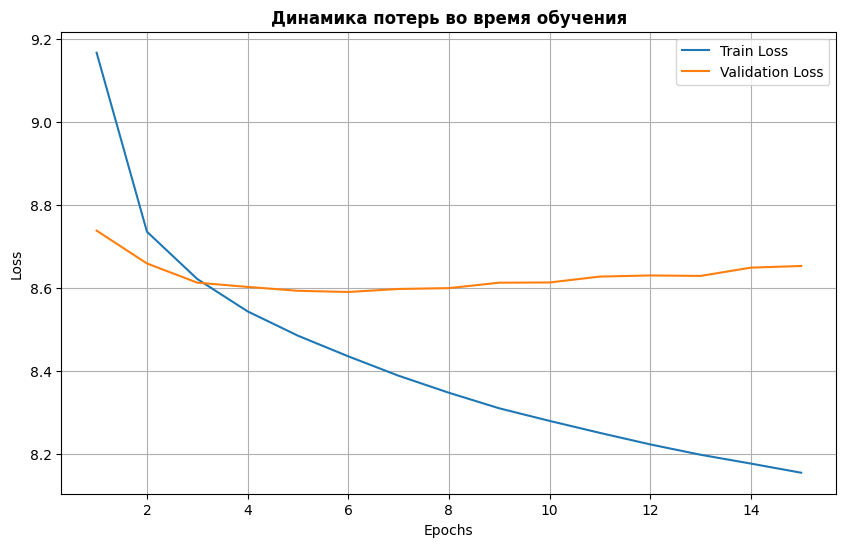

In [ ]:
# добавляю BatchNorm1d

model = nn.Sequential(
    nn.Linear(inputs, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
).to(device)

num_epochs = 15
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

1. Минимальный лосс, которого удалось достичь с Dropout до переобучения - 8.54 на train, 8.54 на validation, такие значения были получены на 10 эпохе, возможно, при увеличении числа эпох можно будет достичь еще большего качества, так как признаков переобучения по графику не видно.

2. Минимальный лосс, которого удалось достичь с BatchNorm1d до переобучения - 8.15 на train, 8.59 на validation, такие значения для валидации были получены на 7 эпохе, после этого модель стала демонстрировать явные признаки переобучения.

*Было принято решение выбрать BatchNorm1d для дальнейшего обучения*

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [ ]:
lrs = [1e-4, 1e-3, 1e-2, 1e-1]
weight_decays = [0, 1e-6, 1e-5, 1e-4, 1e-3]
epochs = 15

results = []

for lr in lrs:
    for wd in weight_decays:
        model = nn.Sequential(
            nn.Linear(inputs, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        criterion = torch.nn.MSELoss()

        train_losses = []
        val_losses = []

        for epoch in range(epochs):
          train_l = training_epoch(model, optimizer, criterion, train_loader)
          val_l = validation_epoch(model, criterion, val_loader)


          train_losses.append(train_l)
          val_losses.append(val_l)

        results.append({
            'lr': lr,
            'weight_decay': wd,
            'train_losses': train_losses,
            'val_losses': val_losses
        })

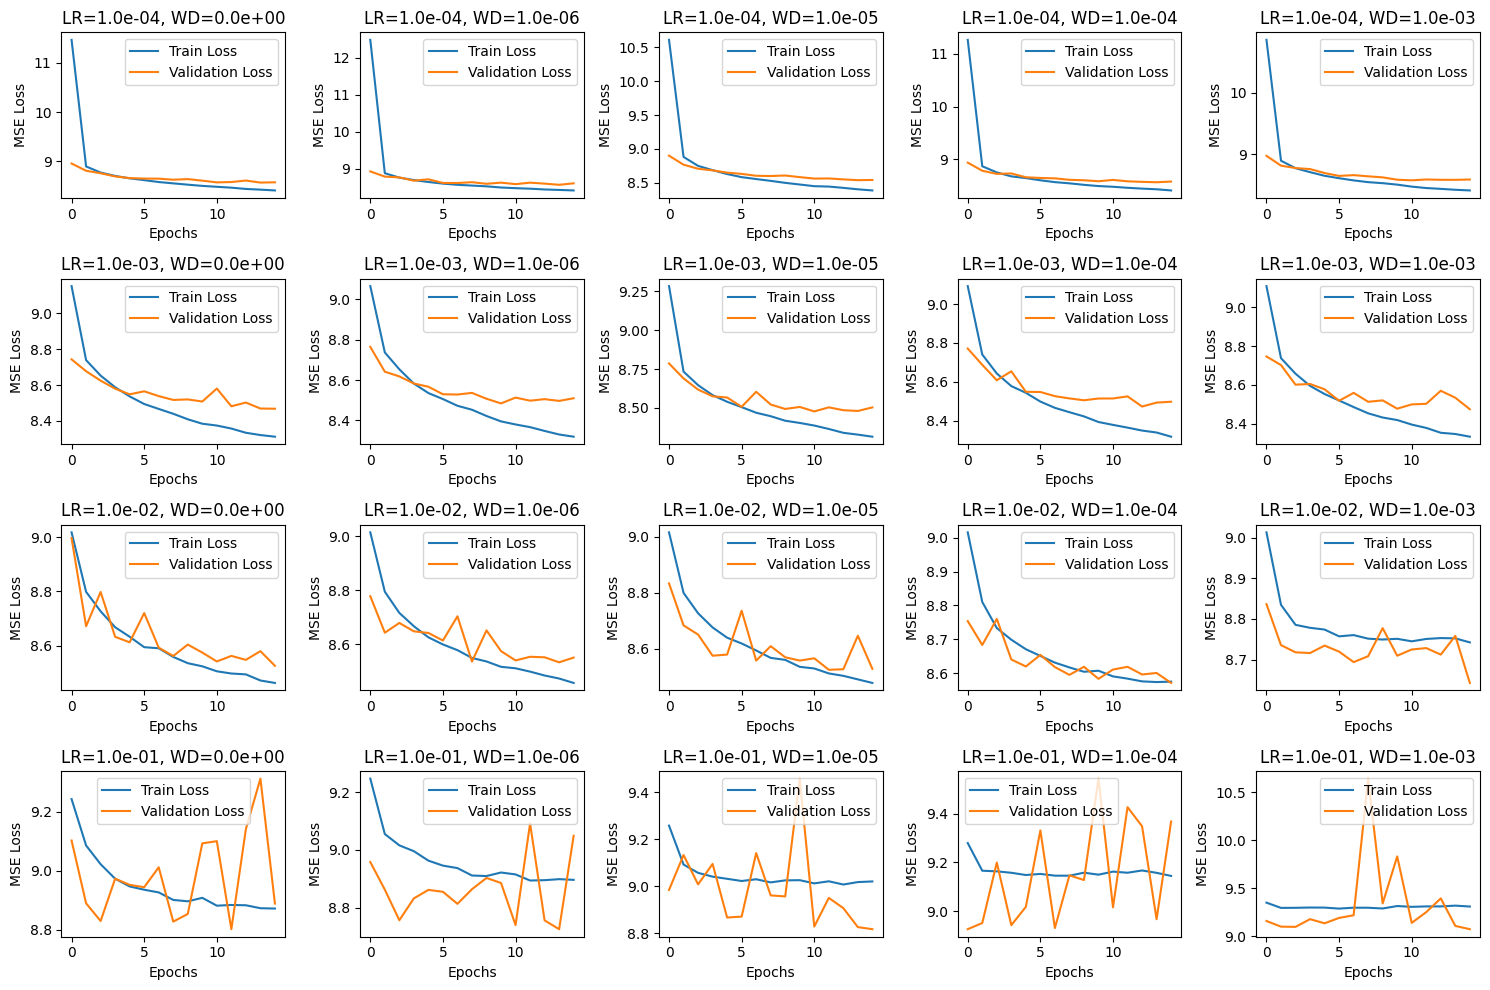

In [ ]:
plt.figure(figsize=(15, 10))

for result in results:
    plt.subplot(len(lrs), len(weight_decays), results.index(result)+1)
    plt.plot(range(num_epochs), result['train_losses'], label='Train Loss')
    plt.plot(range(num_epochs), result['val_losses'], label='Validation Loss')
    plt.title(f'LR={result["lr"]:.1e}, WD={result["weight_decay"]:.1e}')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
min_val_loss_result = min(results, key=lambda x: x['val_losses'][-1])

best_lr = min_val_loss_result['lr']
best_weight_decay = min_val_loss_result['weight_decay']
best_val_loss = min_val_loss_result['val_losses'][-1]

print(f'Оптимальное значение learning rate: {best_lr}')
print(f'Оптимальное значение weight decay: {best_weight_decay}')
print(f'Минимальная loss на валидационном наборе: {best_val_loss}')

Оптимальное значение learning rate: 0.001
Оптимальное значение weight decay: 0
Минимальная loss на валидационном наборе: 8.467628826676767


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

1. Обратим внимание на то, что при увеличении скорости обучения (lr) loss на валидации становится более нестабильным, что приводит к сильным колебаниям кривой обучения.

2. Для того, чтобы процесс обучения был более ускоренным, желательно использовать lr больше 0.0001, судя по графикам, идеально подойдет 0,001.

3. Weight_decay в данной серии экспериментов влияет не так сильно на loss, но видно, что при использовании ненулевых значений на первых эпохах лосс на валидации ниже, чем если бы значение weight_decay было равно нулю.

**Итог:** оптимальные значения гиперпараеметров **lr** = 0,001, **weight_decay** = 0 (попробовать 0,1).

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

Epoch 1/4, Train Loss: 9.0328, Val Loss: 8.6798
Epoch 2/4, Train Loss: 8.6718, Val Loss: 8.5942
Epoch 3/4, Train Loss: 8.5070, Val Loss: 8.5398
Epoch 4/4, Train Loss: 8.3579, Val Loss: 8.5327


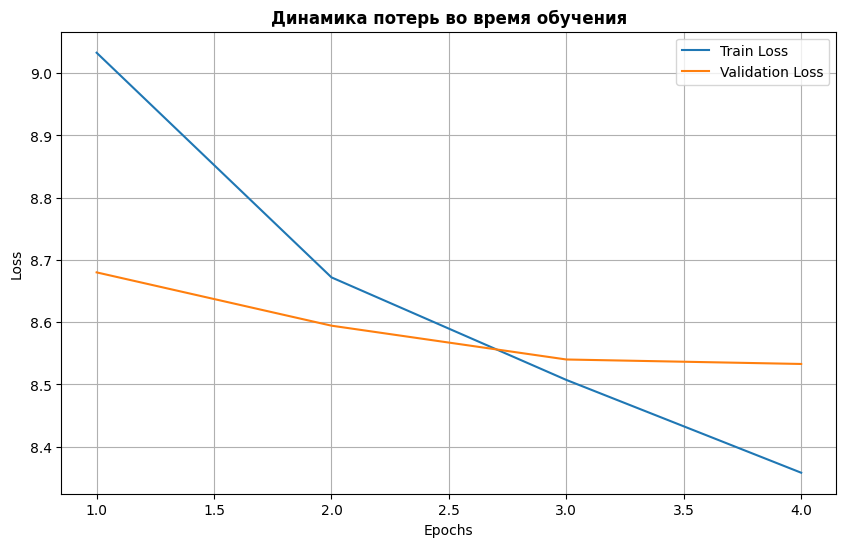

In [ ]:
model = nn.Sequential(
    nn.Linear(inputs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Linear(256, 1),
    nn.Sigmoid(),
).to(device)

num_epochs = 4
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

train(model, optimizer, criterion, train_loader, val_loader, num_epochs)

In [ ]:
from sklearn.metrics import mean_squared_error

test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.float32)), batch_size=batch_size, shuffle=False, generator=g,
                                       worker_init_fn=seed_worker)

# test_preds = model(X_test)
# test_loss = np.mean((Y_scaler.inverse_transform(test_preds.detach().numpy()) -
#                                        Y_scaler.inverse_transform(y_test.detach().numpy()))**2)

# rmse = np.sqrt(mean_squared_error(y_test, predictions))
# print(f"RMSE: {rmse}")

/tmp/ipython-input-2790461571.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
/tmp/ipython-input-2790461571.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_test, dtype=torch.float32)), batch_size=batch_size, shuffle=False, generator=g,


In [ ]:
predictions = predict(model, test_loader)

rmse = np.sqrt(mean_squared_error(denormalize(y_test), denormalize(predictions)))
print(f"RMSE: {rmse}")

RMSE: 8.724915658858356


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ получили качество на тесте 8.72. Поэкспериментировала с шириной слоев в нейронной сети, сделала меньше эпох обучения, исходя из предыдущих экспериментов видно, что при 10 эпохах модель склонна переобучаться. На 4 эпохах модель показала хорошее качество. Увеличение ширины слоев также позволило добиться улучшения качества. В остальном составляющие архитектуры не изменились.

Также был эксперимент с добавлением дополнительного слоя, но сеть стала учиться гораздо дольше, плюс стала сильнее переобучаться.